# Project: Dengue Cases
# Analyst: John Lennon Jarabese

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression
warnings.filterwarnings('ignore')

In [2]:
dengue = pd.read_csv('datasets\\dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


<h1>Changing Datatypes</h1>

In [3]:
dengue['Year'] = dengue['Year'].astype('int')
region_order = ['BARMM', 'CAR', 'NCR', 'Region I', 'Region II', 'Region III', 'Region IV-A', 'Region IV-B', 'Region IX', 'Region V', 'Region VI', 'Region VII', 'Region VIII', 'Region X', 'Region XI', 'Region XII', 'Region XIII']
dengue['Region'] = pd.Categorical(dengue['Region'], categories=region_order, ordered=True)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)
dengue.dtypes

Month            category
Year                int64
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
dtype: object

<h1>Explonatory Data Analysis (EDA)</h1>
<hr>

<h1>1. Which year had the highest total dengue cases?</h1>

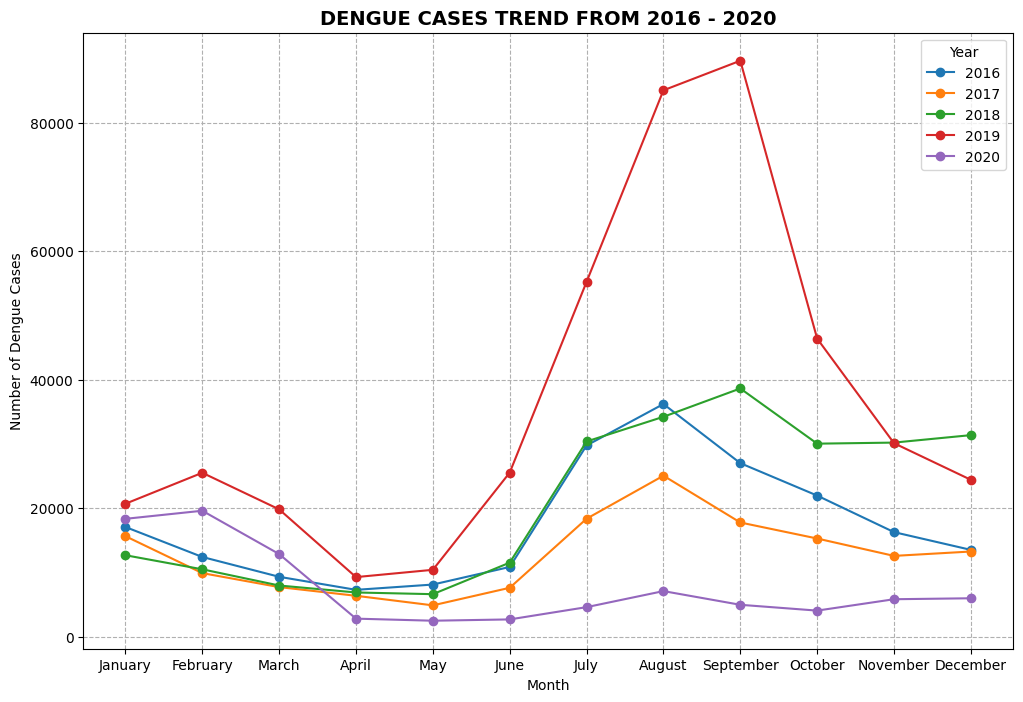

In [6]:
# Group data by Month and Year
monthly_cases = dengue.groupby([dengue.Month, dengue.Year])["Dengue_Cases"].sum()

# Plot the dengue trend by year
monthly_cases.unstack().plot(kind='line', marker='o')
plt.gcf().set_size_inches(12,8)
plt.grid(True, linestyle='--')
plt.xticks(range(0,12), month_order)
plt.title('DENGUE CASES TREND FROM 2016 - 2020', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Dengue Cases')
plt.show()

<h1>Insights:</h1>
<h4 style="font-family: 'Poppins', sans-serif; font-weight: 450; line-height: 1.3;">
1. The line graph shows a clear upward spike in 2019, marking it as the year with the most dengue cases. The sharp increase during July to September highlights how severe the outbreak became nationwide. This sudden jump was partly influenced by weakened public trust in vaccination programs during the Dengvaxia issue. <hr> 2. In 2020, the number of dengue cases dropped noticeably compared to the previous year. This can be connected to the COVID-19 lockdowns, which limited people’s movement and improved sanitation habits. The reduction suggests that cleaner surroundings and restricted travel can help slow down dengue spread.  <hr> 3. From 2016 to 2020, dengue cases followed a seasonal pattern, peaking during the rainy months and declining afterward. The 2019 peak remains the most severe outbreak within this period. Overall, the trend reminds us that early prevention and strong community awareness are key to reducing future dengue cases.
</h4>

<h1>2. Which month shows the peak dengue season across all years?</h1>

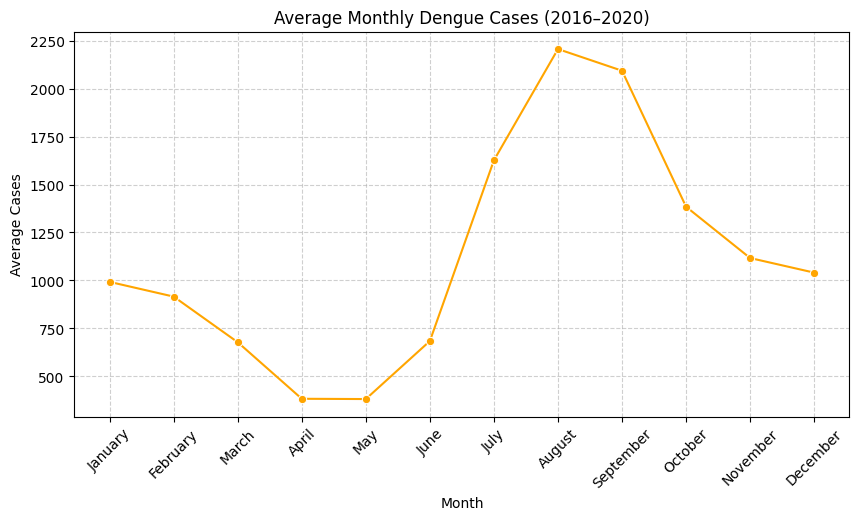

In [10]:
monthly_avg = dengue.groupby('Month')['Dengue_Cases'].mean().reindex([
    'January','February','March','April','May','June','July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='orange')
plt.title('Average Monthly Dengue Cases (2016–2020)')
plt.xlabel('Month')
plt.ylabel('Average Cases')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<h1>Insights:</h1>
<h4 style="font-family: 'Poppins', sans-serif; font-weight: 450; line-height: 1.3;">
4. From the graph, the rainy months of July to September have the highest dengue cases every year. Heavy rains create stagnant water, which becomes a breeding ground for mosquitoes. This pattern shows that dengue spreads faster during wet and humid months. <hr>
5. January to March shows the lowest number of dengue cases, meaning the colder season limits mosquito survival. During these months, mosquitoes reproduce less and the environment becomes less favorable for them. This trend confirms how weather directly affects dengue transmission.
</h4>

<h1>3. DENGUE CASES FOR EACH REGION</h1>

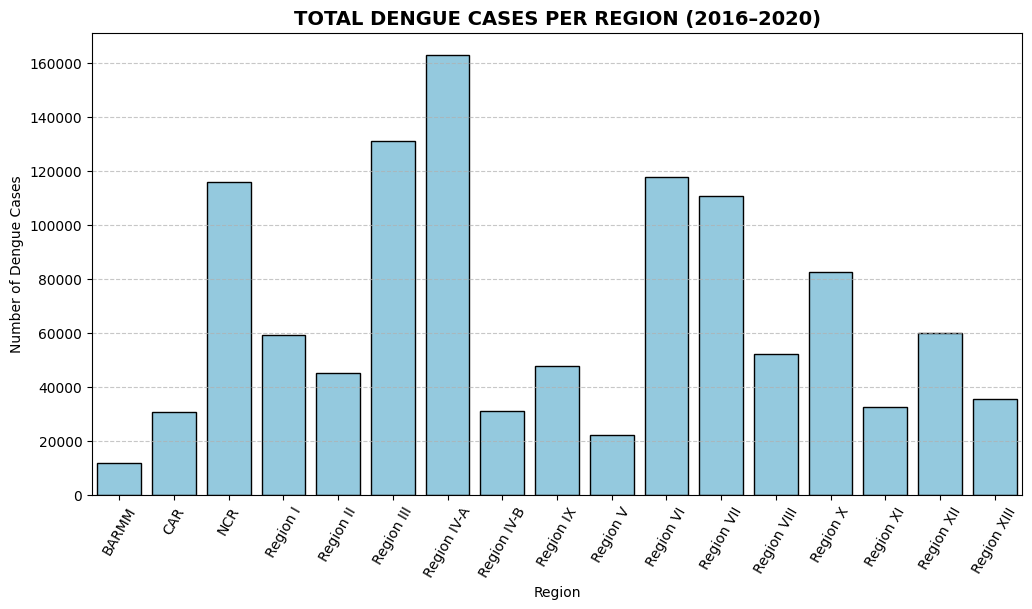

In [25]:
region_cases = dengue.groupby('Region')['Dengue_Cases'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Dengue_Cases', data=region_cases, color='skyblue', edgecolor='black')

plt.xlabel('Region')
plt.ylabel('Number of Dengue Cases')
plt.title('TOTAL DENGUE CASES PER REGION (2016–2020)', fontsize=14, fontweight='bold')
plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<h1>Insights:</h1>
<h4 style="font-family: 'Poppins', sans-serif; font-weight: 450; line-height: 1.3;">
6. Based on the graph, Region IV-A has the highest number of dengue cases from 2016 to 2020. This is understandable because it has a large population and many urban areas where mosquitoes can breed easily. High population density and poor drainage systems can increase the spread of dengue in such regions.<hr>
7. NCR, Region III, Region VI, and Region VII also show consistently high numbers of cases. These are densely populated regions, making mosquito control more challenging. Meanwhile, BARMM and Region V recorded fewer cases, possibly due to smaller populations or fewer reports submitted.</h4>

<h1>4. MORTALITY RATE FOR EACH REGION</h1>

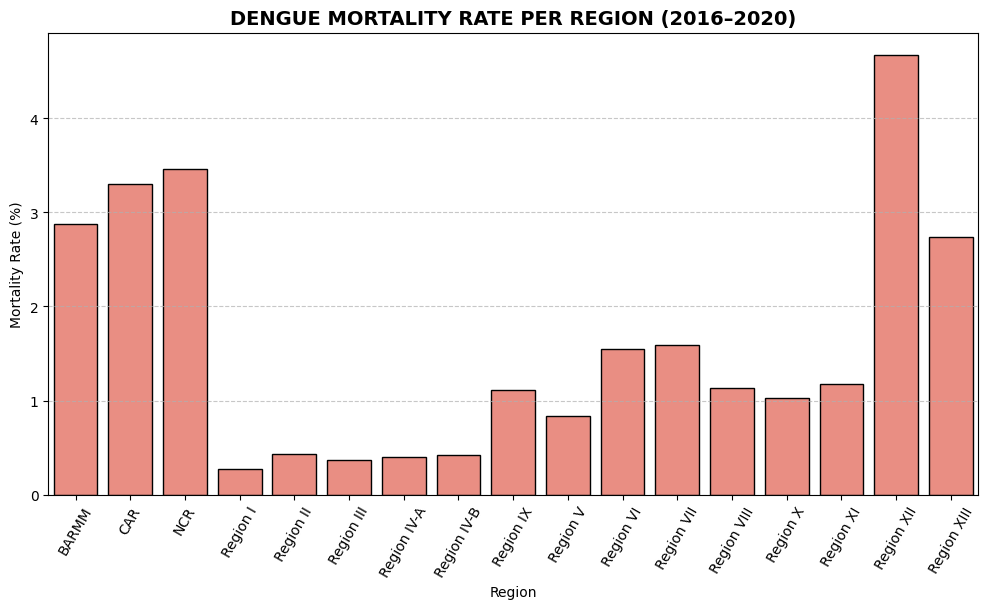

In [26]:
mortality = dengue.groupby(['Region'])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()

mortality['Mortality_Rate'] = np.round((mortality['Dengue_Deaths'] / mortality['Dengue_Cases']) * 100, 2)

plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Mortality_Rate', data=mortality, color='salmon', edgecolor='black')

plt.xlabel('Region')
plt.ylabel('Mortality Rate (%)')
plt.title('DENGUE MORTALITY RATE PER REGION (2016–2020)', fontsize=14, fontweight='bold')
plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<h1>Insights:</h1>
<h4 style="font-family: 'Poppins', sans-serif; font-weight: 450; line-height: 1.3;">
8. The graph shows that Region XII (SOCCSKSARGEN) recorded the highest dengue mortality rate, exceeding 4%. This suggests that the region may have fewer hospitals or slower medical response systems. Limited healthcare access can make dengue more fatal even with fewer cases. <hr>9. In contrast, Regions I, II, III, IV-A, and IV-B recorded the lowest mortality rates, all below 1%. These regions likely benefit from faster diagnosis and better medical attention. It proves that early detection and treatment greatly reduce the number of dengue-related deaths. </h4>

<h1>5. DENGUE DEATHS FOR EACH REGION</h1>

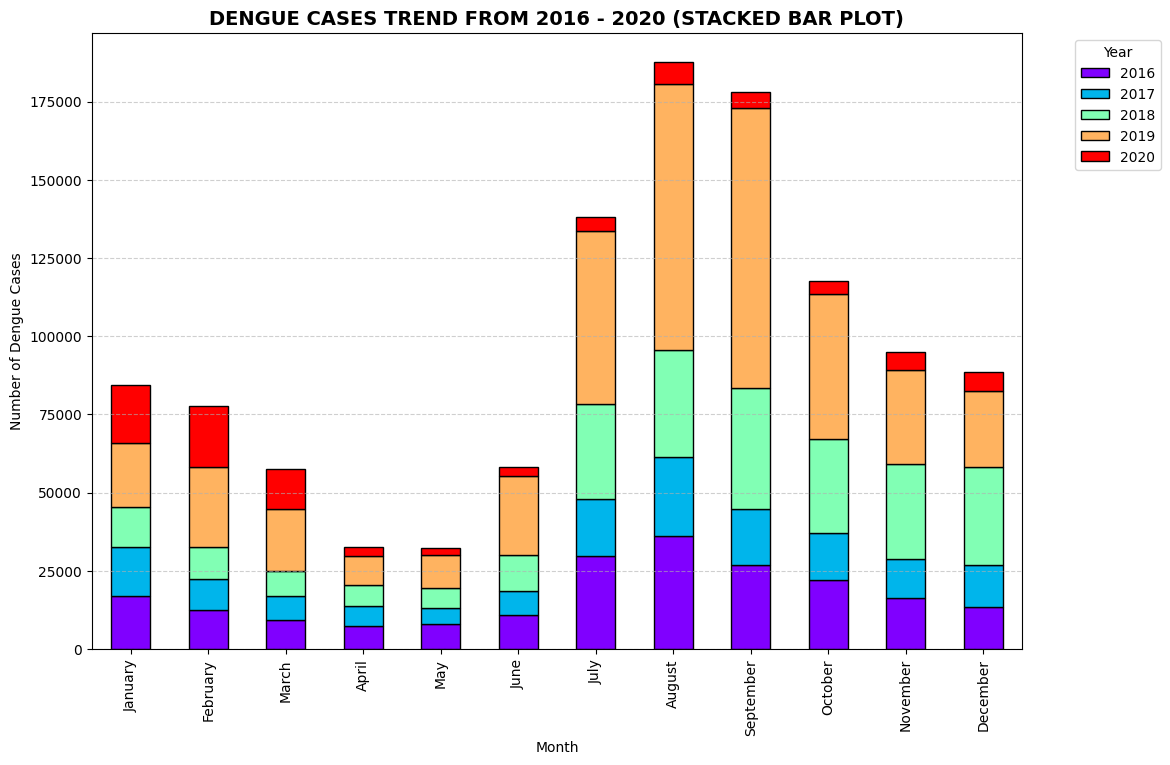

In [29]:
monthly_cases = dengue.groupby([dengue.Month, dengue.Year])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(
    kind='bar',
    stacked=True,
    figsize=(12,8),
    colormap='rainbow',
    edgecolor='black'
)

plt.title('DENGUE CASES TREND FROM 2016 - 2020 (STACKED BAR PLOT)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Dengue Cases')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


<h1>Insight:</h1>
<h4 style="font-family: 'Poppins', sans-serif; font-weight: 450; line-height: 1.3;">
10. The stacked bar plot shows that 2019 had the highest dengue cases, especially between July and September, when cases spiked sharply nationwide. Earlier years like 2016 to 2018 had smaller contributions, and 2020 had noticeably fewer cases. This pattern confirms that dengue outbreaks reach their peak during the rainy season, with 2019 standing out as the most severe year.</h4>